### Singular Value Decomposition (SVD)

#### Definition

Singular Value Decomposition (SVD) is a fundamental matrix factorization technique used in linear algebra. Given an \( m \times n \) matrix \( A \), the SVD is a factorization of the form:

$$
A = U \Sigma V^T
$$

Where:
- $U$ is an $m \times m$ orthogonal matrix.
- $\Sigma$ is an $m \times n$ diagonal matrix with non-negative real numbers on the diagonal (singular values).
- $V$ is an $n \times n$ orthogonal matrix.
- $V^T$ is the transpose of $V$.

#### Properties

1. **Singular Values**:
   - The diagonal elements of $\Sigma$ are the singular values $\sigma_1, \sigma_2, \dots, \sigma_{\min(m,n)}$ of the matrix $A$, arranged in non-increasing order $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_{\min(m,n)} \geq 0$.
   - The number of non-zero singular values equals the rank of the matrix $A$.

2. **Orthogonality**:
   - $U$ and $V$ are orthogonal matrices, meaning $U^T U = I$ and $V^T V = I$, where $I$ is the identity matrix.

3. **Geometric Interpretation**:
   - The columns of $U$ represent the left singular vectors of $A$.
   - The columns of $V$ represent the right singular vectors of $A$.

4. **Energy Compaction**:
   - SVD provides an optimal low-rank approximation of the matrix $A$. The first $k$ singular values capture the most significant features of $A$.

#### Computing the SVD

The SVD can be computed using various algorithms, such as:
- **Jacobi Algorithm**: Iterative method for diagonalizing matrices.
- **Golub-Kahan-Reinsch Algorithm**: A more efficient method based on bidiagonalization.

#### Applications
SVD is a powerful tool for matrix factorization, providing insights into the geometric and algebraic properties of matrices. SVD is widely used in data analysis, signal processing, and machine learning, particularly for tasks like principal component analysis (PCA) and image compression.
- **Matrix approximation, image compression**
- **Solving linear system**
- **Linear regression**
- **Principle Component Analysis (PCA)**


[1.68481034e+01 1.06836951e+00 3.35890790e-16]


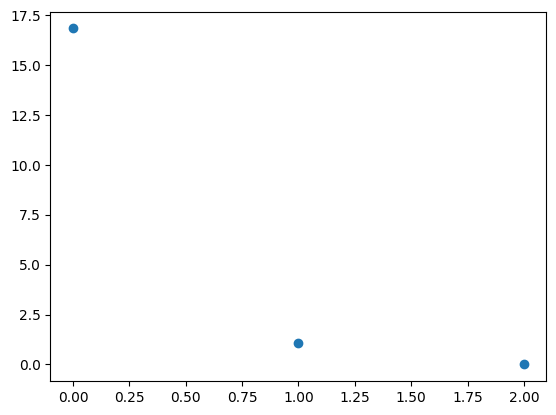

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create a matrix A
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# Compute the SVD
U, Sigma, V_T = np.linalg.svd(A)

# Adjust the figure size
#plt.figure(figsize=(6, 4))
plt.plot(Sigma, 'o')
#plt.yscale('log')
plt.savefig('singular_values.png')
print(Sigma)

In [4]:
# Convert Sigma to a diagonal matrix
Sigma_diag = np.zeros((A.shape[0], A.shape[1]))
np.fill_diagonal(Sigma_diag, Sigma)
# another way to make a diag matrix
S_diag = np.diag(Sigma)

print("Matrix A:")
print(A)
print("\nLeft singular vectors (U):")
print(U)
print("\nSingular values (Sigma):")
print(Sigma_diag)
print("\nRight singular vectors (V^T):")
print(V_T)

Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Left singular vectors (U):
[[-0.21483724  0.88723069  0.40824829]
 [-0.52058739  0.24964395 -0.81649658]
 [-0.82633754 -0.38794278  0.40824829]]

Singular values (Sigma):
[[1.68481034e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.06836951e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.35890790e-16]]

Right singular vectors (V^T):
[[-0.47967118 -0.57236779 -0.66506441]
 [-0.77669099 -0.07568647  0.62531805]
 [-0.40824829  0.81649658 -0.40824829]]


## Economy Singular Value Decomposition (SVD)

The economy Singular Value Decomposition (SVD), also known as the truncated SVD, is a variant of the full SVD that provides a more compact representation of a matrix. Given a matrix $A \in \mathbb{R}^{m \times n}$, the full SVD decomposes $A$ as:

$$
A = U \Sigma V^T
$$

where:
- $U \in \mathbb{R}^{m \times m}$ is an orthogonal matrix (i.e., $U^T U = I_m$),
- $\Sigma \in \mathbb{R}^{m \times n}$ is a diagonal matrix with non-negative real numbers on the diagonal, known as the singular values,
- $V \in \mathbb{R}^{n \times n}$ is an orthogonal matrix (i.e., $V^T V = I_n$).

In the economy SVD, we take advantage of the fact that the matrix $A$ often has rank $k \leq \min(m, n)$. The economy SVD truncates the matrices $U$, $\Sigma$, and $V$ to only include the first $r$ columns or rows corresponding to the non-zero singular values. This results in a more compact representation:

$$
A = U_{m\times m}\Sigma_{m\times n} V_{n\times n}^T=\hat{U}_{m\times k} \hat{\Sigma}_{k\times k} V_{k\times k}^T
$$

where:
- $\hat{U} \in \mathbb{R}^{m \times k}$ contains the first $k$ columns of $U$,
- $\hat{\Sigma} \in \mathbb{R}^{r \times k}$ is a diagonal matrix with the $k$ largest singular values,
- $V \in \mathbb{R}^{n \times k}$ contains the first $k$ columns of $V$.

The economy SVD is particularly useful when $m \gg n$ or $n \gg m$, as it reduces the computational complexity and storage requirements by focusing only on the significant singular values and vectors.

<img src="./figures/svd1.png" alt="Alt text" width="600" height="400">

In [6]:
#economy SVD
# Create a random matrix
A = np.random.rand(6, 3)

# Full SVD
U, S, Vt = np.linalg.svd(A, full_matrices=True)
# perform the economy SVD
Uhat, Shat,Vthat = np.linalg.svd(A, full_matrices=False)
print("Full SVD:")
print("U matrix shape:", U.shape)
print("Singular values S shape:", S.shape)
print("V^T matrix shape:", Vt.shape)

print("Economy SVD:")
print("Uhat matrix shape is:", Uhat.shape)
print("Singular values Shat shape is:", Shat.shape)
print("V^That matrix shape is:", Vthat.shape)

Full SVD:
U matrix shape: (6, 6)
Singular values S shape: (3,)
V^T matrix shape: (3, 3)
Economy SVD:
Uhat matrix shape is: (6, 3)
Singular values Shat shape is: (3,)
V^That matrix shape is: (3, 3)


In [7]:
#A_recon_full = U @ S @Vt
Shat_mat = np.diag(Shat)
print(Shat_mat)
A_recon_economy = Uhat @ Shat_mat @ Vthat
print(np.linalg.norm(A-A_recon_economy))

[[2.38015558 0.         0.        ]
 [0.         0.920385   0.        ]
 [0.         0.         0.53687415]]
7.843405972445216e-16


### Low-rank approximation (Matrix approximation)
Every matrix has a SVD,
$$
A = U_{m\times m}\Sigma_{m\times n} V_{n\times n}^T=\hat{U}_{m\times k} \hat{\Sigma}_{k\times k} V_{k\times k}^T
$$
Approximate matrix A through truncation, $r<k$
$$A\approx \hat{U}_{m\times r} \hat{\Sigma}_{r\times r} V_{r\times r}^T $$
<img src="./figures/svd2.png" alt="Alt text" width="700" height="500">

In [8]:
# Create a random matrix
A = np.random.rand(10, 7)
#A = np.array([[1,2,3,4],[2,3,4,5],[2,3,4,2],[0,2,3,5],[1,5,6,8],[5,0,2,1],[1,2,0,3]])
print(A.shape)
# Perform SVD, economy SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("V shape:", Vt.shape)
print(np.diag(S))

(10, 7)
U shape: (10, 7)
S shape: (7,)
V shape: (7, 7)
[[4.57090346 0.         0.         0.         0.         0.
  0.        ]
 [0.         1.19466974 0.         0.         0.         0.
  0.        ]
 [0.         0.         1.06113249 0.         0.         0.
  0.        ]
 [0.         0.         0.         0.85607712 0.         0.
  0.        ]
 [0.         0.         0.         0.         0.76438528 0.
  0.        ]
 [0.         0.         0.         0.         0.         0.5041179
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.29940021]]


In [9]:
# Choose rank k
k = 5

# Low-rank approximation
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

#A_k is the approximation of A from truncated SVD
A_k = U_k @ S_k @ Vt_k

print("Original Matrix A:")
print(A)
print("\nLow-Rank Approximation A_k:")
print(A_k)
print(np.linalg.norm(A-A_k))

Original Matrix A:
[[4.20180477e-01 3.52497191e-01 2.85749571e-01 2.44152664e-01
  5.11600836e-01 3.28057014e-01 6.21388422e-01]
 [8.71329514e-01 8.54634792e-01 9.48479370e-01 2.56946630e-01
  9.76374830e-01 7.30070222e-01 5.52828204e-01]
 [9.61330267e-01 8.59097235e-06 1.12739202e-01 2.32428565e-01
  2.11978233e-01 1.55944210e-01 9.17053722e-01]
 [2.54978553e-01 3.31552366e-01 9.93399679e-01 5.51116112e-01
  9.67043854e-01 5.75409627e-01 8.40258992e-01]
 [5.65618391e-01 2.60344984e-01 7.11137746e-01 5.09756375e-01
  8.64959246e-01 6.14015801e-01 4.47247037e-01]
 [6.22607637e-01 8.72350495e-01 1.70288974e-01 5.79851346e-01
  5.20956873e-01 8.85457472e-01 2.43496412e-01]
 [9.18230403e-01 1.26740673e-01 7.35216777e-01 1.28282949e-01
  8.12904424e-01 1.45468030e-01 2.63842891e-01]
 [8.16903086e-01 6.54900756e-01 7.87444587e-01 2.51477623e-01
  1.91192879e-02 9.52764555e-01 5.71292223e-01]
 [5.08888849e-01 1.21956501e-01 3.91671429e-01 4.57760298e-02
  1.83480261e-01 7.26766329e-01 1.25376

## image compression

shape of the original image: (2000, 1500, 3)


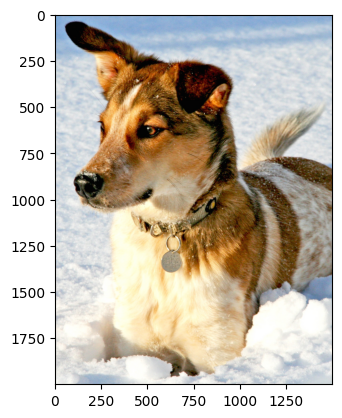

In [10]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
#plt.rcParams['figure.figsize'] = [6, 4]

A = imread('./figures/dog.jpg')
img_ori = plt.imshow(A)
print("shape of the original image:", A.shape)

shape of the Grayscale image: (2000, 1500)


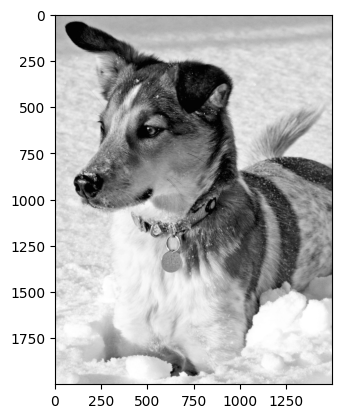

In [11]:
X = np.mean(A, 2); # Convert RGB to grayscale

print("shape of the Grayscale image:", X.shape)
img = plt.imshow(X)
img.set_cmap('gray')
#plt.axis('off')
plt.show()

shape of U: (2000, 1500)
shape of Vt: (1500, 1500)
shape of S: (1500,)


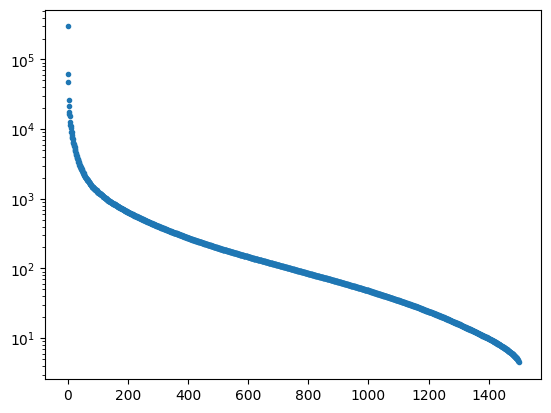

In [13]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)  #economy SVD
print("shape of U:", U.shape)
print("shape of Vt:", Vt.shape)
print("shape of S:", S.shape)
Sdiag = np.diag(S)

plt.plot(S,'.')
plt.yscale('log')

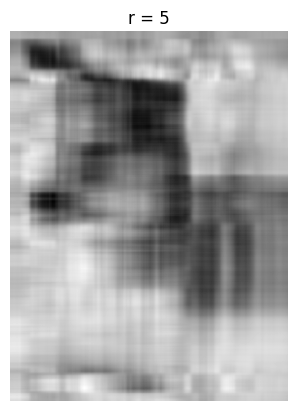

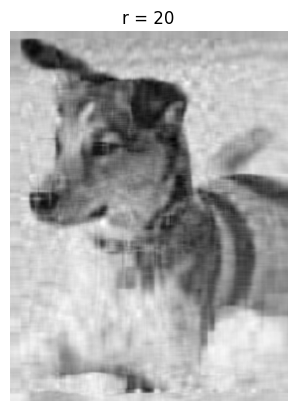

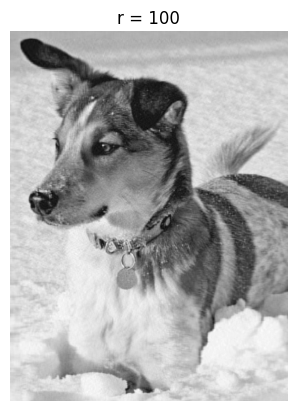

In [14]:
j = 0
for r in (5, 20, 100):
    # Construct approximate image
    Xapprox = U[:,:r] @ Sdiag[0:r,:r] @ Vt[:r,:]
    plt.figure(j+1)
    j += 1
    img = plt.imshow(Xapprox)
    img.set_cmap('gray')
    plt.axis('off')
    plt.title('r = ' + str(r))
    plt.show()

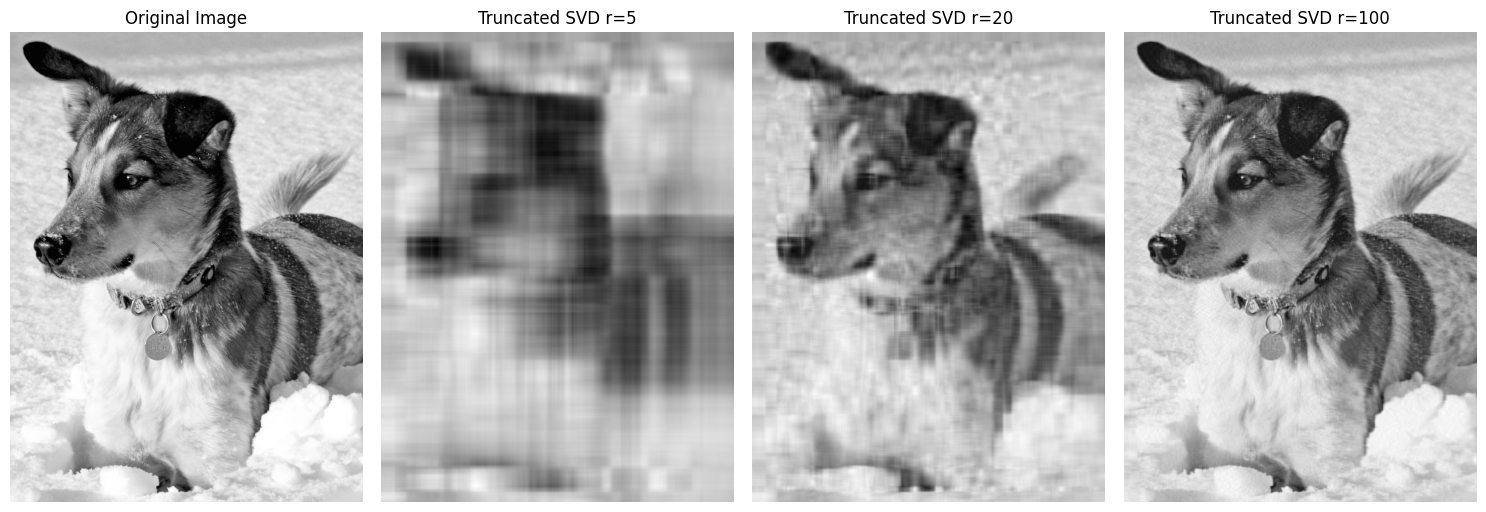

In [15]:
r_values = [5, 20, 100]
#set up the subplots
fig,axs = plt.subplots(1,4, figsize=(15,5))
#plot the original image
axs[0].imshow(X, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')

# loop over each value of r and plot the truncated SVD image
for i,r in enumerate(r_values):
    truncated_image = U[:, :r] @ Sdiag[:r, :r] @Vt[:r,:]
    axs[i+1].imshow(truncated_image, cmap='gray')
    axs[i+1].set_title(f'Truncated SVD r={r}')
    axs[i+1].axis('off')
plt.tight_layout()
plt.show()

## solving a linear system

Consider the linear system $Ax=b$, where A is $m\times n$ matrix, x is $n\times 1$ vector of unknowns, b is $m\times 1$ vector of data (observation).

-Compute SVD of A: 
$$A=\hat{U}\hat{\Sigma}\hat{V}^T$$
$$x=\hat{V}\Sigma^{-1}\hat{U}^Tb$$

## Linear Regression with SVD
linear function $$y = ax + b$$
- a is the slope, b is the intercept
- dataset input $x=[x0,x1,x2,x3]$, output $y=[y0,y1,y2,y3]$
 \begin{align}
ax_0 + b &= y_0 \\
ax_1 + b &= y_1 \\
ax_2 + b &=y_2 \\
ax_3 + b &= y_3
\end{align}
- Form a linear system
  $$\begin{bmatrix}
  x_0 & 1 \\
  x_1 & 1 \\
  x_2 & 1\\
  x_3 & 1
  \end{bmatrix}\begin{bmatrix}
  a\\
  b
  \end{bmatrix}=\begin{bmatrix}
  y_0\\
  y_1\\
  y_2\\
  y_3
  \end{bmatrix}
  $$
- Apply SVD to solve the linear system $\mathbf{A}\mathbf{x}=\mathbf{B}$
  $$\mathbf{X}=\hat{V}\hat{\Sigma}^{-1}\hat{U}^T\mathbf{B}$$

In [16]:
import numpy as np
slope = 3 
x = np.arange(-2, 2, 0.25)
print(x.shape)
print(x)

(16,)
[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75]


In [19]:
a = x.reshape(-1, 1)
y_true = slope*a + 1
y_noise = y_true+np.random.randn(16,1)
print("a shape is:", a.shape)
print("y shape is:", y_true.shape)

a shape is: (16, 1)
y shape is: (16, 1)


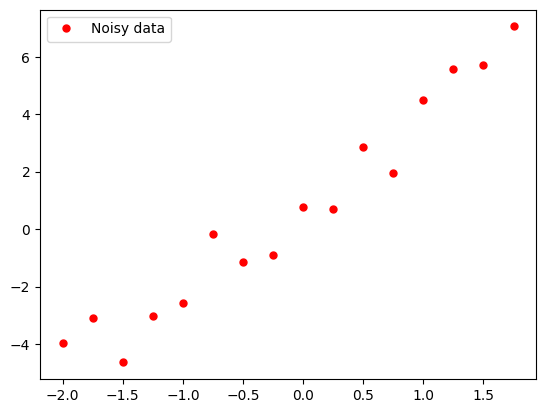

In [20]:
#plt.plot(a, y_true, color='k', linewidth='2', label='true line')
plt.plot(a, y_noise, '.',color='r', markersize=10, label='Noisy data')
plt.legend()

In [21]:
one_vec = np.ones((a.size,1))
print(one_vec)
print(one_vec.shape)

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]
(16, 1)


In [22]:
matA = np.hstack([a,one_vec])
print(matA.shape)
print(matA)

(16, 2)
[[-2.    1.  ]
 [-1.75  1.  ]
 [-1.5   1.  ]
 [-1.25  1.  ]
 [-1.    1.  ]
 [-0.75  1.  ]
 [-0.5   1.  ]
 [-0.25  1.  ]
 [ 0.    1.  ]
 [ 0.25  1.  ]
 [ 0.5   1.  ]
 [ 0.75  1.  ]
 [ 1.    1.  ]
 [ 1.25  1.  ]
 [ 1.5   1.  ]
 [ 1.75  1.  ]]


In [23]:
U, S, Vt = np.linalg.svd(matA, full_matrices=False)
inverse_S_diag = np.diag(1/S)
print(inverse_S_diag)
print(U.shape)
print(Vt.shape)
print(y_true.shape)

[[0.21247583 0.        ]
 [0.         0.25524134]]
(16, 2)
(2, 2)
(16, 1)


In [24]:
B = Vt.T @ inverse_S_diag @ U.T @y_true

In [25]:
print(B.shape)

(2, 1)


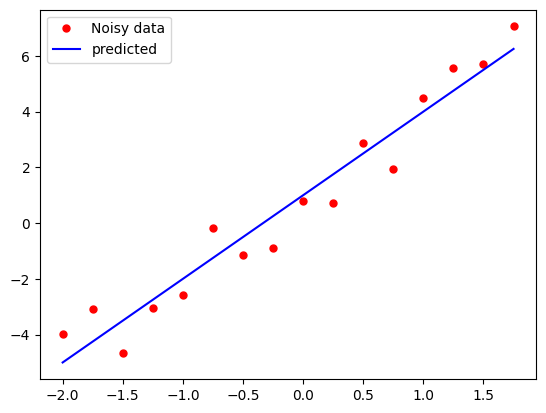

In [26]:
y_pred = B[0]*a + B[1]
#plt.plot(a, y_true, color='k', linewidth='2', label='true line')
plt.plot(a, y_noise, '.',color='r', markersize=10, label='Noisy data')
plt.plot(a, y_pred, 'b-', label='predicted')
plt.legend()

## Polynomial Regression
$n-$th order polynomial function, $y =f(x_1,x_2...,x_n)=a_0 + a_1x + a_2x^2 + a_3x^3+...+a_nx^n$
$$\begin{bmatrix}
1 & x_0^{} & x_0^{2} & x_0^{3} &... & x_0^{n}\\
1 & x_1^{} & x_1^{2} & x_1^{3} &... & x_1^{n}\\
1 & x_2^{} & x_2^{2} & x_2^{3} &... & x_2^{n}\\
\vdots \\
1 & x_m^{} & x_m^{2} & x_m^{3} &... & x_m^{n}
\end{bmatrix}_{m\times n+1}\begin{bmatrix}
a_0\\
a_1\\
a_2\\
\vdots \\
a_n
\end{bmatrix}_{n+1\times 1}=\begin{bmatrix}
y_1\\
y_2\\
\vdots \\
y_m
\end{bmatrix}_{m\times 1}
$$
- $x, x^2,...,x^n$ are the polynomial function degree. $a_0, a_1, a_2,...,a_n$ are the coefficients of the polynomial.
- The goal is to determine the coefficients based on the given $m$ dataset.
- Matrix A is the data, called design matrix, $m>>n$ in general.
- In matrix notation, $A \mathbf{x}= \mathbf{b}$, solve $x$ by using SVD of $A$.

## Fit a second order polynomial
$$y = a_0 + a_1x + a_2x^2$$
$$\begin{bmatrix}
1 & x_0^{} & x_0^{2} \\
1 & x_1^{} & x_1^{2} \\
1 & x_2^{} & x_2^{2} \\
\vdots \\
1 & x_m^{} & x_m^{2} 
\end{bmatrix}_{m\times 3}\begin{bmatrix}
a_0\\
a_1\\
a_2\\
\vdots \\
a_n
\end{bmatrix}_{3\times 1}=\begin{bmatrix}
y_1\\
y_2\\
\vdots \\
y_m
\end{bmatrix}_{m\times 1}
$$

In [27]:
# Generate some data for a second-order polynomial y = a0 + a1*x + a2*x^2
np.random.seed(42)
n_samples = 100  # this is the number of data points
x = np.linspace(-5, 5, n_samples)
a0, a1, a2 = 2.0, -1.0, 0.5  # True coefficients
noise = np.random.normal(0, 1, n_samples)
y = a0 + a1 * x + a2 * x**2 + noise  # Noisy observations

print("x shape is:", x.shape)
print("y shape is:", y.shape)

# Construct the design matrix A for second-order polynomial fitting
X = np.vstack([np.ones(n_samples), x, x**2]).T
print(X.shape)

x shape is: (100,)
y shape is: (100,)
(100, 3)


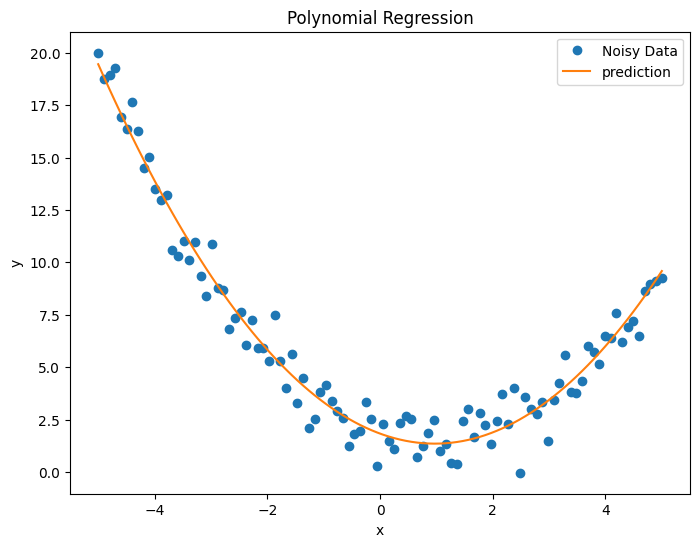

In [29]:
#perfom the economy SVD
U, Sigma, Vt = np.linalg.svd(X, full_matrices=False)

#compute the inverse of Sigma
inverse_S = np.diag(1/Sigma)

#compute the coefficients
coeffs = Vt.T @ inverse_S @ U.T @ y

#compute the prediction
y_pred = X @ coeffs

#plot the solution
plt.figure(figsize=(8,6))
plt.plot(x, y, 'o', label='Noisy Data')
plt.plot(x, y_pred, '-', label='prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()

## Multi-variate Linear Regression
$n-$dimensional linear function, $y =f(x_1,x_2...,x_n)=a_0 + a_1x_1 + a_2x_2 + a_3x_3+...+a_nx_n$
$$\begin{bmatrix}
1 & x_1^{(1)} & x_2^{(1)} & x_3^{(1)} &... & x_n^{(1)}\\
1 & x_1^{(2)} & x_2^{(2)} & x_3^{(2)} &... & x_n^{(2)}\\
1 & x_1^{(3)} & x_2^{(3)} & x_3^{(3)} &... & x_n^{(3)}\\
\vdots \\
1 & x_1^{(m)} & x_2^{(m)} & x_3^{(m)} &... & x_n^{(m)}
\end{bmatrix}_{m\times n}\begin{bmatrix}
a_0\\
a_1\\
a_2\\
\vdots \\
a_n
\end{bmatrix}_{n\times 1}=\begin{bmatrix}
y_1\\
y_2\\
\vdots \\
y_m
\end{bmatrix}_{m\times 1}
$$
- $x_1, x_2,...,x_n$ are offen called features, $a_0, a_1, a_2,...,a_n$ are the parameters of the linear model.
- The goal is to determine the parameters based on the given $m$ dataset.
- Matrix A is called feature matrix, $m>>n$ in general.
- In matrix notation, $A \mathbf{x}= \mathbf{b}$, solve $x$ by using SVD of $A$.
- In practice, feature selection is often applied.